[2024-09-20 14:33:46,103][connect:74] Socket connected


                                   Date    Open    High     Low   Close
Date                                                                   
2024-01-02 23:00:00 2024-01-02 23:00:00  184.05  185.58  183.15  183.94
2024-01-03 23:00:00 2024-01-03 23:00:00  181.83  182.79  180.59  181.64
2024-01-04 23:00:00 2024-01-04 23:00:00  181.64  182.46  179.90  180.78
2024-01-07 23:00:00 2024-01-07 23:00:00  181.83  185.30  181.22  185.23
2024-01-08 23:00:00 2024-01-08 23:00:00  183.63  184.85  182.45  184.80
...                                 ...     ...     ...     ...     ...
2024-04-24 22:00:00 2024-04-24 22:00:00  169.25  170.28  167.89  169.62
2024-04-25 22:00:00 2024-04-25 22:00:00  169.55  171.07  168.93  169.06
2024-04-28 22:00:00 2024-04-28 22:00:00  173.01  175.75  172.86  173.19
2024-04-29 22:00:00 2024-04-29 22:00:00  172.91  174.71  169.77  169.90
2024-04-30 22:00:00 2024-04-30 22:00:00  169.54  172.43  168.84  169.10

[83 rows x 5 columns]
2024-01-02 23:00:00
2024-04-30 22:00:00


/tmp/ipykernel_37400/3163419329.py:44: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range(start_date, end_date, freq='1H')


NameError: name 'axlist' is not defined

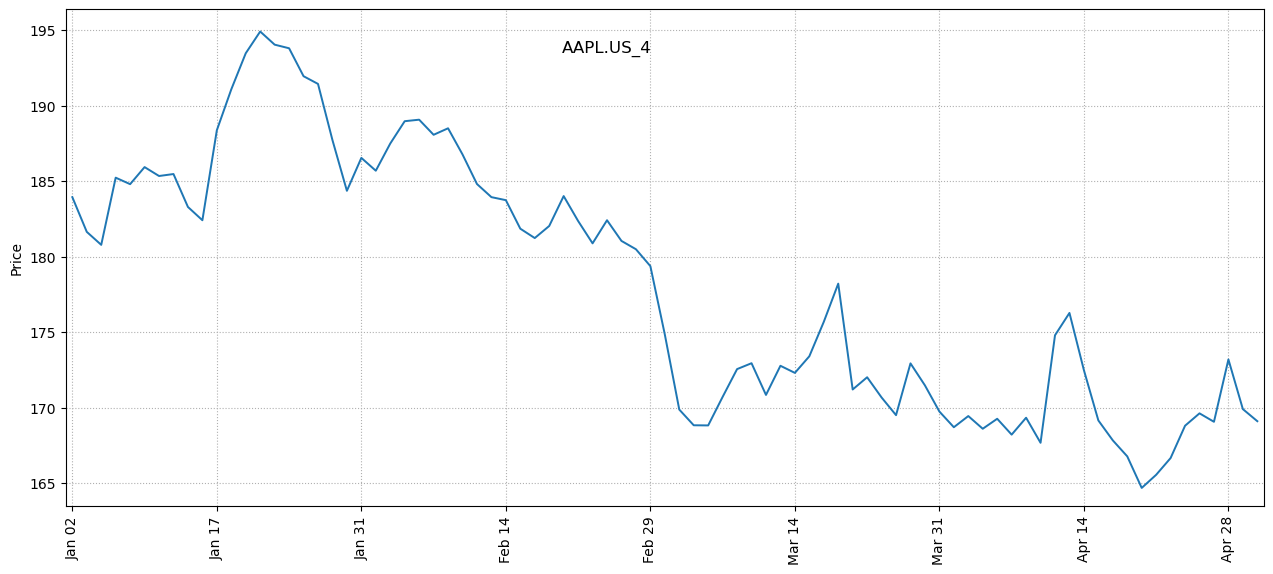

In [1]:
import sys, os, datetime, time, warnings
sys.path.append('../xtb')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf
from datetime import datetime
from DataCollectorXtb import DataCollectorXtb 

collector=DataCollectorXtb(symbol='AAPL.US_4', start='2024-01-01', end='2024-05-01', period='1D',
                spread_col=False, cols_to_save=['Date','Open', 'High', 'Low','Close'])

df = collector.data
df.columns = ['Date', 'Open', 'High', 'Low', 'Close']

df.set_index('Date')
df.index = pd.to_datetime(collector.data.Date)

print(df)


start_date = df['Date'].iloc[0]
end_date = df['Date'].iloc[-1]

print(start_date)
print(end_date)

title = 'AAPL.US_4'
mc = mpf.make_marketcolors(up='g',down='r',inherit=True)
s  = mpf.make_mpf_style(marketcolors=mc, gridaxis='both', gridstyle='dotted')

mpf.plot(collector.data,style=s, 
	datetime_format='%b %d',
	type='line',
	title=title,
	ylabel='Price',
	xrotation=90,
	tight_layout=True,
	figratio=(12,5),
	figscale=1,
	returnfig=True
	)

idx = pd.date_range(start_date, end_date, freq='1H')
df_label_idx = pd.DataFrame(index=idx)

df_label = pd.merge(df_label_idx, df, how='inner', left_index=True, right_index=True )

# Tick labels are generated based on df_label
tick_labels = list(df_label.index.strftime('%H:%M'))
ticklocations = [df.index.get_loc(tick) for tick in df_label.index ]

axlist[-2].xaxis.set_ticks(ticklocations)
axlist[-2].set_xticklabels(tick_labels)

mpf.show()
